# Out of distribution testing of the DeLAN network and model comparison
This notebook is dedicated to evaluating and comparing the generalization capabilities of pre-trained robotic models on Out-of-Distribution (OOD) datasets.
*   Assesses model performance on data distributions not seen during training, specifically targeting robust torque estimation across varying trajectories.

*   Facilitates a direct comparison between a Shallow Network and a Deep Network to analyze how architectural depth affects generalization.

*   Implements the PklDataset class to load OOD data while applying the mean and standard deviation statistics from the original training set to ensure  consistency.

*   Loads model weights and optimizer states from checkpoints stored on Google Drive, allowing for immediate testing of finalized training runs.
*   Calculates Mean Squared Error (MSE) and Normalized MSE (nMSE) both globally and on a per-joint basis to identify specific axis-related performance drops

*   Includes dedicated plotting functions to visualize predicted vs. real torques over time, alongside error residuals, providing qualitative insights into model drift.


*   Generates summary bar plots to visualize the performance gap between shallow and deep architectures across all robot joints.



In [51]:
import numpy as np
import pandas as pd
import pickle as pkl
import matplotlib.pyplot as plt
import glob
import os
import random
import torch
import re # regular expressions


import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [52]:
from google.colab import drive

In [53]:
drive.flush_and_unmount()

In [54]:
drive.mount('/content/drive')

Mounted at /content/drive


## NETWORK DEFINITION

In [55]:
class Net(nn.Module):

    def __init__(self, Ni, Nh1, Nh2, No):
        """
        Ni - Input size
        Nh1 - Neurons in the 1st hidden layer
        Nh2 - Neurons in the 2nd hidden layer
        No - Output size
        """
        super().__init__()

        self.fc1 = nn.Linear(Ni, Nh1)
        self.fc2 = nn.Linear(Nh1, Nh2)
        self.out = nn.Linear(Nh2, No)
        self.act = nn.ReLU()

    def forward(self, x, additional_out=False):

        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        x = self.out(x)
        return x

In [56]:
import sys
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import glob
import re
import random
import pandas as pd
import pickle as pkl
from torch.utils.data import DataLoader, TensorDataset
from torch.utils.data import Dataset
from torchvision import transforms


repo_path = '/content/drive/MyDrive/NNDL_PROGETTO/IMPLEMENTAZIONE DELAN E INPUT SIN COS/deep_lagrangian_networks'
sys.path.append(repo_path)

# Importa il modello DeLAN (verifica il nome del file nella repo clonata, solitamente è in 'models')
try:
    from deep_lagrangian_networks.DeLaN_model import DeepLagrangianNetwork
except ImportError:
    # Fallback se la struttura delle cartelle è diversa, prova a cercare direttamente
    print("Tentativo di importazione alternativo...")


n_dof = 7
# --- PARAMETRI MODELLO ---
# DeLAN richiede di specificare la dimensione dei layer interni
# H1, H2 sono i neuroni per layer per apprendere le matrici di massa e potenziale
hidden_units = [128, 256, 128]

# Inizializzazione Modello
# Nota: Verifica i parametri esatti in base alla versione della repo scaricata.
# Solitamente richiede (n_dof, num_hidden_units, ...)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DeepLagrangianNetwork(n_dof, hidden_units=hidden_units).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn = nn.MSELoss()

## Definizione classe PklDataset

In [57]:
import re
import glob
import os
import pandas as pd
import numpy as np
import random
from torch.utils.data import Dataset

class PklDataset(Dataset):
    """
    Dataset class to load and process robotic state data from pickle files.
    Expected data includes joint positions (q), velocities (dq),
    accelerations (ddq), and noiseless torques (tau).
    """
    def __init__(self, pkl_folder, random_choice=False, transform=None, normalize_y=False, conv_sin_cos=False):
        self.transform = transform
        self.normalize_y = normalize_y
        self.conv_sin_cos = conv_sin_cos

        # Extract Degrees of Freedom (DOF) from folder name using regex
        match = re.search(r"(\d+)dof", pkl_folder)
        if not match:
            raise ValueError(f"Unable to extract DOF from folder name: {pkl_folder}")
        self.n_dof = int(match.group(1))

        # Generate column names based on DOFn
        columns = [f"{prefix}_{j}" for j in range(1, self.n_dof+1) for prefix in ("q", "dq", "ddq")]
        columns += [f"tau_noiseless_{j}" for j in range(1, self.n_dof+1)]

        # Retrieve all pickle files in the specified directory
        pkl_files = glob.glob(os.path.join(pkl_folder, "*.pkl"))
        X_list, Y_list = [], []

        # Load data: either all files or a single random file
        if not random_choice:
            for file_path in pkl_files:
                df = pd.read_pickle(file_path)
                np_array = df[columns].to_numpy()
                # Split features (q, dq, ddq) from targets (tau)
                X_list.append(np_array[:, :(3*self.n_dof)])
                Y_list.append(np_array[:, (3*self.n_dof):])
        else:
            file_path = random.choice(pkl_files)
            df = pd.read_pickle(file_path)
            np_array = df[columns].to_numpy()
            X_list.append(np_array[:, :(3*self.n_dof)])
            Y_list.append(np_array[:, (3*self.n_dof):])

        # Concatenate all loaded data into single numpy arrays
        self.X = np.vstack(X_list)
        self.Y = np.vstack(Y_list)

        # Compute statistics for Y normalization (mean and standard deviation)
        self.mean_y = np.mean(self.Y, axis=0)
        self.std_y = np.std(self.Y, axis=0)
        # Prevent division by zero by setting zero-std to 1
        self.std_y[self.std_y == 0] = 1

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        x, y = self.X[idx], self.Y[idx]

        # Trigonometric encoding for joint positions: maps q -> [sin(q), cos(q)]
        if self.conv_sin_cos:
            q   = x[0::3]       # Extract q components
            dq  = x[1::3]       # Extract dq components
            ddq = x[2::3]       # Extract ddq components

            # Efficiently build the output array: shape (4 * n_dof,)
            x_out = np.empty(4 * self.n_dof, dtype=np.float32)
            x_out[0::4] = np.sin(q)
            x_out[1::4] = np.cos(q)
            x_out[2::4] = dq
            x_out[3::4] = ddq
        else:
            x_out = x.astype(np.float32)

        y_out = y.astype(np.float32)

        # Apply normalization to the output targets if enabled
        if self.normalize_y:
            y_out = (y_out - self.mean_y) / self.std_y

        sample = (x_out, y_out)

        # Apply external transformations
        if self.transform:
            sample = self.transform(sample)

        return sample

In [58]:
class ToTensor(object):
    """Convert numpy arrays to torch tensors."""
    def __call__(self, sample):
        import torch
        x, y = sample
        return (torch.from_numpy(x).float(), torch.from_numpy(y).float())

composed_transform = transforms.Compose([ToTensor()])

In [59]:
n_dof = 7
train_dataset = PklDataset(f'/content/drive/MyDrive/NNDL_PROGETTO/data_generation/{n_dof}dof/train_data/', transform=composed_transform, normalize_y=True)
test_dataset = PklDataset(f'/content/drive/MyDrive/NNDL_PROGETTO/data_out_of_distribution/{n_dof}dof/', transform=composed_transform)

In [60]:
mean_y = train_dataset.mean_y
std_y = train_dataset.std_y

In [61]:
test_dataloader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=0)

In [62]:
# Check if the GPU is available
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Training device: {device}")

Training device: cpu


In [63]:
# Initialize the network
torch.manual_seed(0)
Ni = (3*n_dof)
Nh1 = 128
Nh2 = 256
No = n_dof
net_shallow = Net(Ni, Nh1, Nh2, No)
net_shallow.to(device)

Net(
  (fc1): Linear(in_features=21, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=256, bias=True)
  (out): Linear(in_features=256, out_features=7, bias=True)
  (act): ReLU()
)

## Loss function

In [64]:
# Define the loss function
loss_fn = nn.MSELoss()

def mse_per_joint(pred, target):
    criterion = nn.MSELoss(reduction='none')
    loss = criterion(pred, target).mean(dim = 0)
    return loss

In [65]:
optimizer_shallow = optim.Adam(net_shallow.parameters(), lr=1e-3)

# Load network

In [69]:
checkpoint_shallow = torch.load(f'/content/drive/MyDrive/NNDL_PROGETTO/models_normalized_mse/shallow/{n_dof}dof/checkpoint_epoch50.pt', map_location=device if device.type == "cpu" else None,
    weights_only=False)

net_shallow.load_state_dict(checkpoint_shallow["model_state_dict"])
optimizer_shallow.load_state_dict(checkpoint_shallow["optimizer_state_dict"])
start_epoch_shallow = checkpoint_shallow["epoch"] + 1# riparti dalla successiva
train_loss_log_shallow = checkpoint_shallow["train_loss_log"]
val_loss_log_shallow = checkpoint_shallow["val_loss_log"]
train_loss_joints_log_shallow = checkpoint_shallow["train_loss_joints_log"]
val_loss_joints_log_shallow = checkpoint_shallow["val_loss_joints_log"]

print(f"Epoch {start_epoch_shallow}")

Epoch 50


In [70]:
checkpoint_delan = torch.load(f'/content/drive/MyDrive/NNDL_PROGETTO/models_DELAN/{n_dof}dof/checkpoint_epoch50.pt', map_location=device if device.type == "cpu" else None,
    weights_only=False)

model.load_state_dict(checkpoint_delan["model_state_dict"])
optimizer.load_state_dict(checkpoint_delan["optimizer_state_dict"])
start_epoch = checkpoint_delan["epoch"]  # riparti dalla successiva
train_loss_log = checkpoint_delan["train_loss_log"]
val_loss_log = checkpoint_delan["val_loss_log"]
train_loss_nmse_log = checkpoint_delan["train_loss_nmse_log"]
val_loss_nmse_log = checkpoint_delan["val_loss_nmse_log"]
train_loss_joints_log = checkpoint_delan["train_loss_joints_log"]
val_loss_joints_log = checkpoint_delan["val_loss_joints_log"]
train_loss_nmse_per_joint_log = checkpoint_delan["train_loss_nmse_per_joint_log"]
val_loss_nmse_per_joint_log = checkpoint_delan["val_loss_nmse_per_joint_log"]



print(f"Riprendo da epoca {start_epoch}")

Riprendo da epoca 49


## Comparative Performance Analysis on data out of distribution

=== SHALLOW NETWORK ===
AVERAGE TEST LOSS: 4.352114677429199
TEST LOSS JOINTS: [1.8409194e+00 1.4660802e+01 8.8185244e+00 4.6868968e+00 2.0335986e-01
 2.5339493e-01 9.2976866e-04]

=== DEEP NETWORK ===
AVERAGE TEST LOSS: 11.252691268920898
TEST LOSS JOINTS: [ 1.5120006 24.515608  11.265106  17.039284   4.58722    4.137097
 15.712481 ]


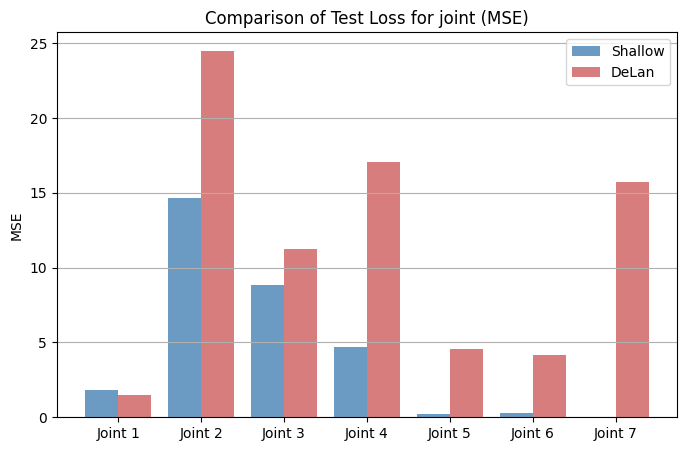

In [77]:
# SPIEGARE BENE CHE SI TRATTA DI MSE ERROR
def evaluate_network(net, test_dataloader, device, mean_y, std_y, test_data_normalized = False, is_deLAN = False):
    """
    Funzione per valutare una rete su test set.
    Ritorna outputs, labels, test_loss medio e per giunto.
    """
    all_inputs = []
    all_outputs = []
    all_labels = []
    test_loss = []
    test_loss_joints = []

    net.eval()  # Evaluation mode (e.g. disable dropout)
    with torch.no_grad():  # Disable gradient tracking
        if is_deLAN:
          for sample_batched in test_dataloader:

            x_batch = sample_batched[0].to(device)
            tau = sample_batched[1].to(device)

            n_joints = x_batch.shape[1] // 3

            q   = x_batch[:, 0::3]
            dq  = x_batch[:, 1::3]
            ddq = x_batch[:, 2::3]

            out = net(q, dq, ddq)
            out = out[0]

            loss = loss_fn(out, tau)
            loss_per_joints = torch.mean((out - tau)**2, dim=0)

            # Save val loss for this batch
            test_loss.append(loss.cpu().numpy())
            test_loss_joints.append(loss_per_joints.cpu().numpy())

            # Save outputs and labels
            all_inputs.append(torch.cat([q, dq, ddq], dim=1))  # corretto
            all_outputs.append(out)
            all_labels.append(tau)
        else:
          for sample_batched in test_dataloader:
              # Move data to device
              x_batch = sample_batched[0].to(device)
              label_batch = sample_batched[1].to(device)


                        # Forward pass
              out = net(x_batch)

              out = out * std_y + mean_y

              # Loss
              loss = loss_fn(out, label_batch)
              loss_per_joints = mse_per_joint(out, label_batch)

              # Save val loss for this batch
              test_loss.append(loss.cpu().numpy())
              test_loss_joints.append(loss_per_joints.cpu().numpy())

              # Save outputs and labels
              all_inputs.append(x_batch)
              all_outputs.append(out)
              all_labels.append(label_batch)

    # Concatenate all the outputs and labels in a single tensor
    all_inputs  = torch.cat(all_inputs)
    all_outputs = torch.cat(all_outputs)
    all_labels  = torch.cat(all_labels)

    test_loss = np.mean(test_loss)
    test_loss_joints = np.mean(np.vstack(test_loss_joints), axis=0)

    return all_inputs, all_outputs, all_labels, test_loss, test_loss_joints

mean_y_tensor = torch.tensor(mean_y).float().to(device)
std_y_tensor = torch.tensor(std_y).float().to(device)

# Evaluating the shallow net
inputs_shallow, outputs_shallow, labels_shallow, test_loss_shallow, test_loss_joints_shallow = evaluate_network(
    net_shallow, test_dataloader, device, mean_y_tensor, std_y_tensor
)
print("=== SHALLOW NETWORK ===")
print(f"AVERAGE TEST LOSS: {test_loss_shallow}")
print(f"TEST LOSS JOINTS: {test_loss_joints_shallow}")

# --- Valutazione rete deep ---
inputs_deep, outputs_deep, labels_deep, test_loss_deep, test_loss_joints_deep = evaluate_network(model, test_dataloader, device, mean_y_tensor, std_y_tensor, is_deLAN=True)
print("\n=== DEEP NETWORK ===")
print(f"AVERAGE TEST LOSS: {test_loss_deep}")
print(f"TEST LOSS JOINTS: {test_loss_joints_deep}")


# --- Confronto grafico per giunto ---
n_joints = test_loss_joints_shallow.shape[0]
x = np.arange(n_joints)

plt.figure(figsize=(8,5))
plt.bar(x - 0.2, test_loss_joints_shallow, width=0.4, label="Shallow",  alpha=0.8, color='steelblue')
plt.bar(x + 0.2, test_loss_joints_deep, width=0.4, label="DeLan",  alpha=0.8, color='indianred')
plt.xticks(x, [f"Joint {i+1}" for i in range(n_joints)])
plt.ylabel("MSE")
plt.title("Comparison of Test Loss for joint (MSE)")
plt.legend()
plt.grid(True, axis="y")
plt.show()



=== SHALLOW NETWORK ===
AVERAGE TEST LOSS: 1.320210576057434
TEST LOSS JOINTS: [1.5853951e+00 4.9661722e+00 1.9279557e+00 6.7325246e-01 4.1030426e-02
 4.6956904e-02 7.1153336e-04]


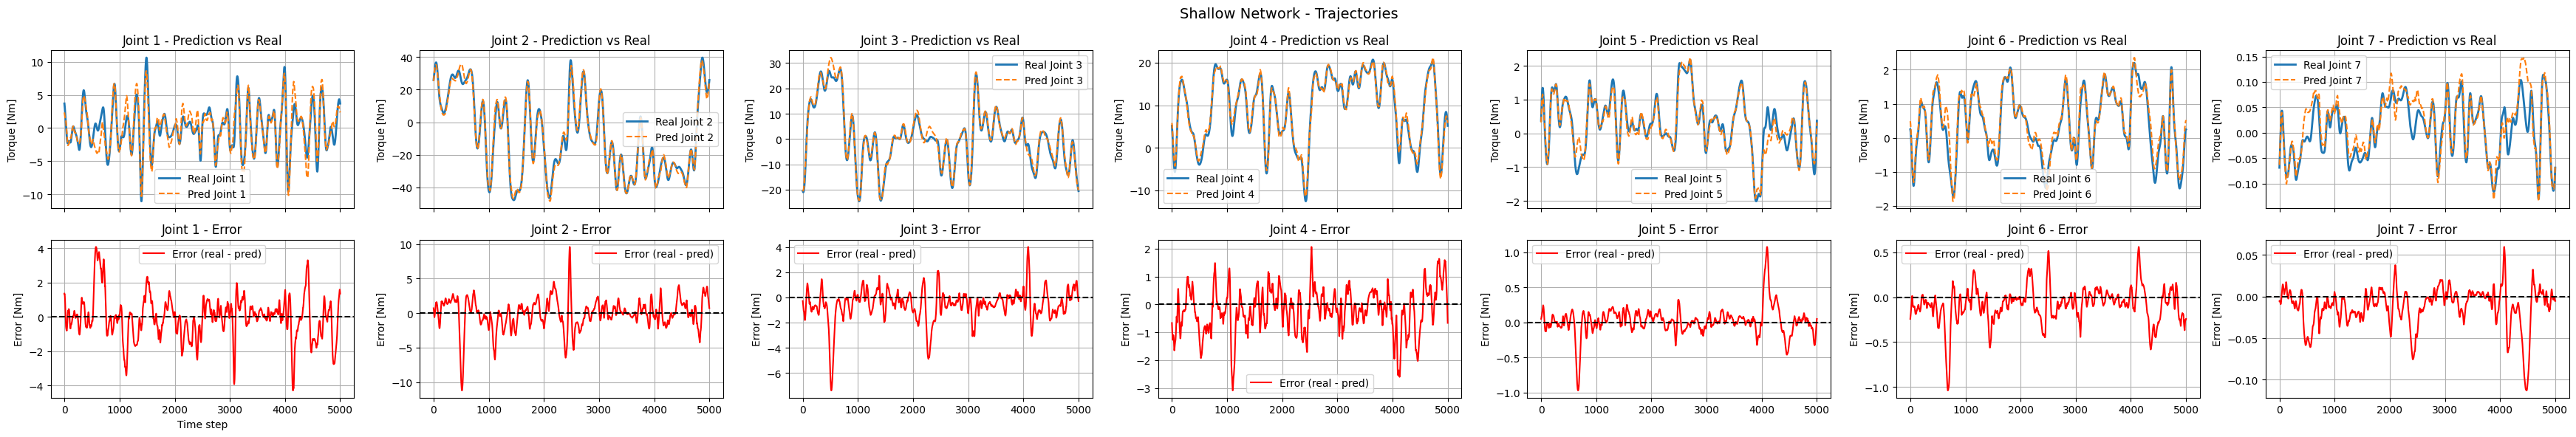


=== DEEP NETWORK ===
AVERAGE TEST LOSS: 4.720714092254639
TEST LOSS JOINTS: [ 0.54296035 14.900918    5.2800627   9.6982355   0.88918275  0.9553612
  0.7782854 ]


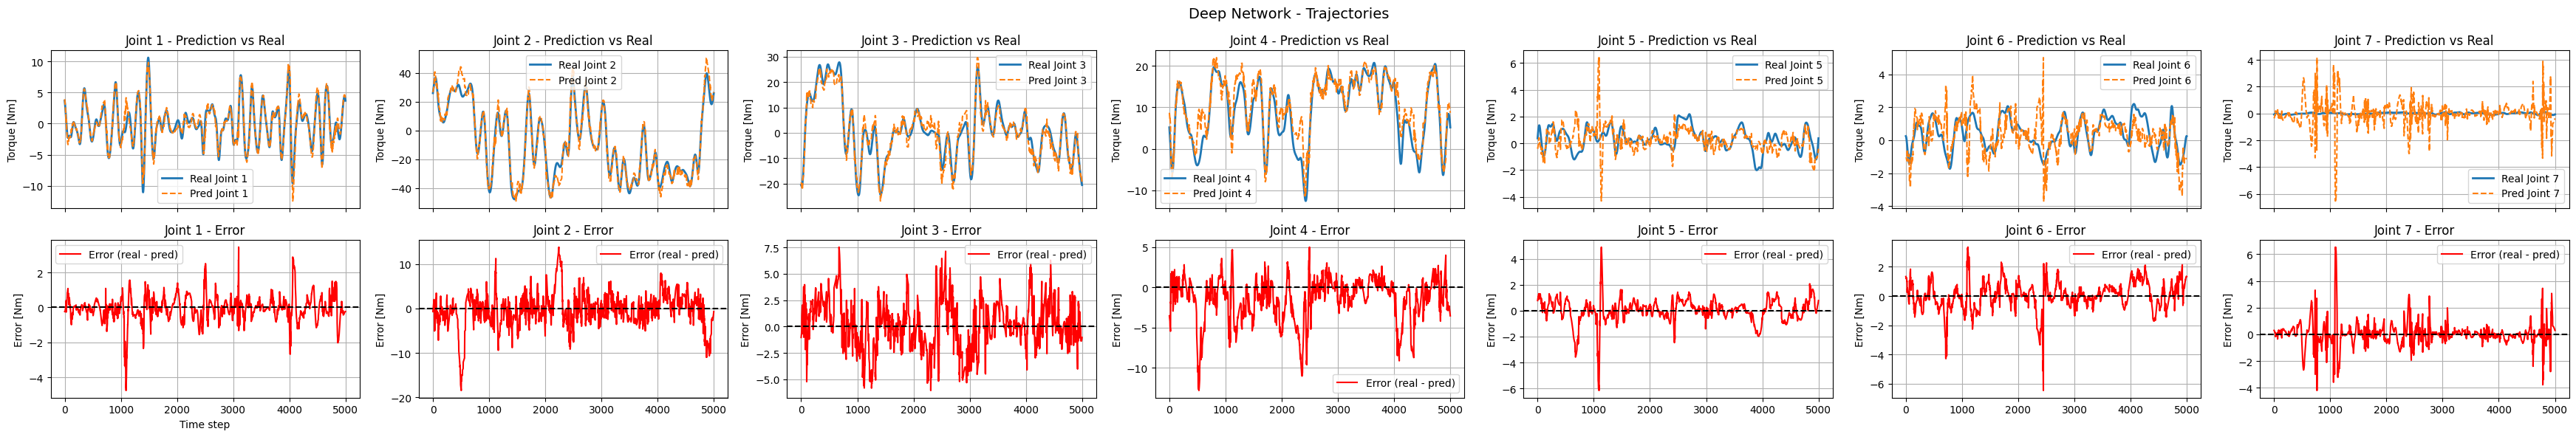

In [79]:
# === CREATE OOD DATASET ===
test_trajectory_dataset = PklDataset(
    f'/content/drive/MyDrive/NNDL_PROGETTO/data_out_of_distribution/{n_dof}dof/',
    random_choice=True,
    transform=composed_transform
)
test_trajectory_dataloader = DataLoader(
    test_trajectory_dataset, batch_size=64, shuffle=False, num_workers=0
)


# === PLOT FUNCTION ===
def plot_joint_trajectories(outputs, labels, title="Predicted vs Real Torques and Errors"):
    """
    Plots predicted vs ground truth and residuals for each joint.
    """
    # Convert to numpy
    outputs = outputs.cpu().numpy()
    labels = labels.cpu().numpy()

    n_samples, n_joints = outputs.shape
    time = np.arange(n_samples)

    fig, axes = plt.subplots(2, n_joints, figsize=(5*n_joints, 6), sharex=True)
    if n_joints == 1:
        axes = axes.reshape(2, 1)

    # --- Trajectories ---
    for j in range(n_joints):
        axes[0, j].plot(time, labels[:, j], label=f"Real Joint {j+1}", linewidth=2)
        axes[0, j].plot(time, outputs[:, j], label=f"Pred Joint {j+1}", linestyle="--")
        axes[0, j].set_ylabel("Torque [Nm]")
        axes[0, j].legend()
        axes[0, j].grid(True)
        axes[0, j].set_title(f"Joint {j+1} - Prediction vs Real")

    # --- Residuals ---
    errors = labels - outputs
    for j in range(n_joints):
        axes[1, j].plot(time, errors[:, j], color="red", label="Error (real - pred)")
        axes[1, j].axhline(0, color="black", linestyle="--")
        axes[1, j].set_ylabel("Error [Nm]")
        axes[1, j].legend()
        axes[1, j].grid(True)
        axes[1, j].set_title(f"Joint {j+1} - Error")

    axes[1, 0].set_xlabel("Time step")
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


# === EVALUATION ===
# Shallow network
inputs_shallow, outputs_shallow, labels_shallow, test_loss_shallow, test_loss_joints_shallow = evaluate_network(
    net_shallow, test_trajectory_dataloader, device, mean_y_tensor, std_y_tensor, is_deLAN=False
)
print("=== SHALLOW NETWORK ===")
print(f"AVERAGE TEST LOSS: {test_loss_shallow}")
print(f"TEST LOSS JOINTS: {test_loss_joints_shallow}")
plot_joint_trajectories(outputs_shallow, labels_shallow, title="Shallow Network - Trajectories")

# Deep / DeLAN network
inputs_deep, outputs_deep, labels_deep, test_loss_deep, test_loss_joints_deep = evaluate_network(
    model, test_trajectory_dataloader, device, mean_y_tensor, std_y_tensor, is_deLAN=True
)
print("\n=== DEEP NETWORK ===")
print(f"AVERAGE TEST LOSS: {test_loss_deep}")
print(f"TEST LOSS JOINTS: {test_loss_joints_deep}")
plot_joint_trajectories(outputs_deep, labels_deep, title="Deep Network - Trajectories")